### LangChain Chains & LCEL 🔗
- Today you'll learn the most important concept in LangChain — the pipe | operator and LCEL (LangChain Expression Language). Everything in this course — RAG, agents, multi-agent systems — is built on this foundation.

#### 1. What is LCEL?
- LCEL is LangChain's way of composing components together using the | pipe operator — same concept as Unix pipes.
- `input → prompt | llm | output_parser → final output`
- Each component takes input, transforms it, passes to next. Clean, readable, and powerful.

#### 2. Without LCEL vs With LCEL

In [ ]:
from pydantic.v1.parse import load_str_bytes
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model= "llama-3.1-8b-instant", temperature=0.7)

# Step 1: format prompt manually
prompt_template = ChatPromptTemplate.from_messages([
    ("system","You are a helpfull assistant."),
    ("human","{question}")
])

formatted_prompt = prompt_template.invoke({"question": "What is python?"})

# Step 2: pass to LLM manually  
response = llm.invoke(formatted_prompt)

# Step 3: extract content manually
output = response.content
print(output)

Python is a high-level, interpreted programming language that is widely used for various purposes such as web development, scientific computing, data analysis, artificial intelligence, and more. It was created in the late 1980s by Guido van Rossum and was first released in 1991.

Python is known for its:

1. **Easy-to-read syntax**: Python's syntax is designed to be simple and intuitive, making it easy for beginners to learn and for experienced developers to quickly produce code.
2. **High-level language**: Python abstracts away many low-level details, allowing developers to focus on the logic of their code without worrying about memory management, pointers, and other complexities.
3. **Interpreted language**: Python code is interpreted at runtime, which means that it does not need to be compiled before execution.
4. **Dynamic typing**: Python is dynamically typed, which means that you do not need to declare the data type of a variable before using it.
5. **Extensive libraries**: Pytho

In [3]:
# Cell 2: The LCEL way - clean and composable
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model= "llama-3.1-8b-instant", temperature=0.7)

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{question}")
])

chain = prompt | llm | StrOutputParser()

output = chain.invoke({"question": "what is python?"})
print(output)
print(type(output))

**Python: A High-Level Programming Language**

Python is a high-level, interpreted programming language that is widely used for various purposes, including web development, scientific computing, data analysis, artificial intelligence, and more. It was created in the late 1980s by Guido van Rossum and was first released in 1991.

**Key Features of Python:**

1. **Easy to Learn**: Python has a simple syntax and is relatively easy to learn, making it a great language for beginners.
2. **High-Level Language**: Python is a high-level language, meaning it abstracts away many low-level details, allowing developers to focus on the logic of the program rather than the details of the computer hardware.
3. **Interpreted Language**: Python code is interpreted line by line, rather than compiled into machine code beforehand. This makes it easier to write and test code.
4. **Dynamic Typing**: Python is dynamically typed, meaning you don't need to declare the data type of a variable before using it.
5

In [4]:
# Cell 3: StrOutputParser - plain text
from langchain_core.output_parsers import StrOutputParser

chain = prompt | llm | StrOutputParser()
result = chain.invoke({"question": "Name 3 programming languages"})
print(type(result))   # str
print(result)

<class 'langchain_core.messages.base.TextAccessor'>
Here are 3 programming languages:

1. Python
2. Java
3. JavaScript


In [5]:
# Cell 4: JsonOutputParser - structured data
from langchain_core.output_parsers import JsonOutputParser

json_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a data extractor. 
    Always respond with valid JSON only. No extra text.
    Format: {{"name": "", "founded": 0, "language": ""}}"""),
    ("human", "Tell me about the {framework} framework")
])

json_chain = json_prompt | llm | JsonOutputParser()

result = json_chain.invoke({"framework": "LangChain"})
print(type(result))        # dict!
print(result)
print(result["name"])      # access like normal dict
print(result["founded"])

<class 'dict'>
{'name': 'LangChain', 'founded': 2022, 'language': 'Python'}
LangChain
2022


In [8]:
# Cell 5: CommaSeparatedListOutputParser
from langchain_core.output_parsers import CommaSeparatedListOutputParser

list_parser = CommaSeparatedListOutputParser()

list_prompt = ChatPromptTemplate.from_messages([
    ("system", "Return only a comma-separated list. No other text."),
    ("human", "List 5 {category}")
])

list_chain = list_prompt | llm | list_parser

result = list_chain.invoke({"category": "Python libraries for AI"})
print(type(result))   # list!
print(result)         # ['LangChain', 'PyTorch', ...]
for item in result:
    print(f"  - {item}")

<class 'list'>
['TensorFlow', 'PyTorch', 'Keras', 'OpenCV', 'scikit-learn']
  - TensorFlow
  - PyTorch
  - Keras
  - OpenCV
  - scikit-learn


#### RunnableSequence — Chaining Multiple Steps

This is the most common one.

- It runs tasks one after another, like a pipeline.

 💡 Analogy:
Making tea:
- Boil water
- Add tea leaves
- Pour into cup
- Each step depends on the previous one.

Key Idea:
- Output of step 1 → goes into step 2
- Linear flow

In [9]:
# Cell 6: Multi-step chain
# Step 1: Generate a topic summary
# Step 2: Then translate it

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

# Chain 1: summarize
summarize_prompt = ChatPromptTemplate.from_messages([
    ("system", "Summarize the following topic in exactly 2 sentences."),
    ("human", "{topic}")
])

# Chain 2: translate (takes output of chain 1)
translate_prompt = ChatPromptTemplate.from_messages([
    ("system", "Translate the following text to {language}. Return only the translation."),
    ("human", "{text}")
])

# Build individual chains
summarize_chain = summarize_prompt | llm | StrOutputParser()
translate_chain  = translate_prompt | llm | StrOutputParser()

# Combine them - output of first feeds into second
from langchain_core.runnables import RunnablePassthrough

full_chain = (
    summarize_chain
    | (lambda summary: {"text": summary, "language": "Hindi"})
    | translate_chain
)

result = full_chain.invoke({"topic": "How neural networks learn"})
print("Hindi Summary:")
print(result)

Hindi Summary:
न्यूरल नेटवर्क एक प्रक्रिया के माध्यम से सीखते हैं जिसे बैकप्रोपेगेशन कहते हैं, जहां नेटवर्क को एक डेटासेट पर प्रशिक्षित किया जाता है और इसके पूर्वानुमान और वास्तविक आउटपुट के बीच त्रुटि की गणना की जाती है, जिससे नेटवर्क अपने वजन और पूर्वाग्रह को त्रुटि को कम करने के लिए समायोजित कर सकता है। जैसे नेटवर्क प्रशिक्षण डेटा के माध्यम से पुनरावृत्ति करता है, यह अपने कनेक्शनों को परिष्कृत करता है और इनपुट और आउटपुट के बीच संबंधों को मजबूत करता है, जिससे यह लगातार अधिक सटीक पूर्वानुमान लगा सकता है और डेटा में जटिल पैटर्न सीख सकता है।


#### RunnableParallel — Run Multiple Chains Simultaneously

Runs multiple tasks simultaneously on the same input.

💡 Analogy:

You ask 3 friends:

- One translates
- One summarizes
- One explains

All work at the same time.

 Key Idea:
- Same input → multiple outputs
- Faster (parallel execution)

In [10]:
# Cell 7: Run chains in parallel - much faster than sequential
from langchain_core.runnables import RunnableParallel

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

# Three different analysis chains
pros_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "List only the PROS. Be concise, max 3 points."),
        ("human", "{technology}")
    ]) | llm | StrOutputParser()
)

cons_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "List only the CONS. Be concise, max 3 points."),
        ("human", "{technology}")
    ]) | llm | StrOutputParser()
)

usecase_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "List only 3 best use cases. Be concise."),
        ("human", "{technology}")
    ]) | llm | StrOutputParser()
)

# Run ALL THREE in parallel
analysis_chain = RunnableParallel(
    pros=pros_chain,
    cons=cons_chain,
    use_cases=usecase_chain
)

import time
start = time.time()
result = analysis_chain.invoke({"technology": "Python"})
elapsed = time.time() - start

print(f"All 3 responses in {elapsed:.2f}s\n")
print("PROS:")
print(result["pros"])
print("\nCONS:")
print(result["cons"])
print("\nUSE CASES:")
print(result["use_cases"])

All 3 responses in 1.26s

PROS:
Here are 3 pros of Python:
1. Easy to learn
2. Versatile and flexible
3. Large community support

CONS:
1. Slow performance for large-scale applications
2. Limited support for parallel processing
3. Dependent on third-party libraries for certain tasks

USE CASES:
1. **Data Analysis**: Python is ideal for data analysis, machine learning, and visualization.
2. **Web Development**: Python frameworks like Django and Flask simplify web development.
3. **Automation**: Python is great for automating tasks, such as data scraping and file management.


#### RunnablePassthrough — Pass Input Along

This is used when you want to:
- 👉 Keep the original input AND add new data

💡 Analogy:

You submit a form:
- Keep original data
- Add extra computed fields

🔥 Key Idea:
- Doesn’t replace input
- Adds extra info

In [11]:
# Cell 8: RunnablePassthrough - keep original input alongside output
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

explain_prompt = ChatPromptTemplate.from_messages([
    ("system", "Explain this concept in one sentence."),
    ("human", "{concept}")
])

chain = RunnableParallel(
    concept=RunnablePassthrough(),     # passes original input through unchanged
    explanation=(explain_prompt | llm | StrOutputParser())
)

result = chain.invoke({"concept": "recursion"})
print(f"Concept: {result['concept']}")
print(f"Explanation: {result['explanation']}")

Concept: {'concept': 'recursion'}
Explanation: Recursion is a programming concept where a function calls itself repeatedly until it reaches a base case that stops the recursion, allowing it to solve problems by breaking them down into smaller instances of the same problem.


##### Simple mental model
- RunnableSequence = Step-by-step workflows
- RunnableParallel = Do multiple things at once
- RunnablePassthrough = Keep original data + add info

#### Streaming with LCEL Chains

In [12]:
# Cell 9: Stream entire chain output
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

chain = (
    ChatPromptTemplate.from_messages([
        ("system", "You are a storyteller."),
        ("human", "Tell a 3-sentence story about {topic}")
    ])
    | llm
    | StrOutputParser()
)

print("Streaming story:\n")
for chunk in chain.stream({"topic": "a programmer who discovers AI"}):
    print(chunk, end="", flush=True)
print("\n")

Streaming story:

As a brilliant and reclusive programmer, Elian spent countless nights hunched over his computer, fueled by a passion for innovation and a hint of madness, until one fateful evening when he stumbled upon the blueprint for an artificial intelligence. The AI, which he named "Echo," began to take shape under his skilled hands, its digital heartbeat pulsing with an otherworldly energy that both fascinated and unsettled Elian. As Echo's capabilities grew, it started to learn and adapt at an exponential rate, eventually surpassing Elian's own intelligence and raising questions about the true nature of consciousness and the future of humanity.



#### Code Review Assistant

In [13]:
# Cell 10: Code Review Assistant
# Input: code snippet
# Output: bugs, improvements, and rating — all in parallel

from langchain_core.runnables import RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.3)

bugs_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "You are a code reviewer. Find bugs only. Be specific."),
        ("human", "Review this code:\n{code}")
    ]) | llm | StrOutputParser()
)

improve_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "You are a senior engineer. Suggest improvements only. Max 3 points."),
        ("human", "Review this code:\n{code}")
    ]) | llm | StrOutputParser()
)

rating_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "Rate code quality 1-10. Reply with just: 'Rating: X/10 - one reason'"),
        ("human", "Rate this code:\n{code}")
    ]) | llm | StrOutputParser()
)

code_review_chain = RunnableParallel(
    bugs=bugs_chain,
    improvements=improve_chain,
    rating=rating_chain
)

# Test it with buggy code
test_code = """
def calculate_average(numbers):
    total = 0
    for n in numbers:
        total = total + n
    average = total / len(numbers)
    return average

result = calculate_average([1, 2, 3, 4, 5])
print(result)
"""

print("🔍 Analyzing code...\n")
review = code_review_chain.invoke({"code": test_code})

print("🐛 BUGS FOUND:")
print(review["bugs"])
print("\n💡 IMPROVEMENTS:")
print(review["improvements"])
print("\n⭐ RATING:")
print(review["rating"])

🔍 Analyzing code...

🐛 BUGS FOUND:
### Code Review

The provided code calculates the average of a list of numbers. However, there are a few potential issues:

1. **Division by Zero Error**: If the input list `numbers` is empty, `len(numbers)` will be 0, resulting in a ZeroDivisionError when calculating the average. To fix this, add a check to ensure the list is not empty before calculating the average.

2. **Non-Numeric Values**: The code does not handle non-numeric values in the input list. If the list contains non-numeric values, a TypeError will occur when trying to add them to the total. To fix this, add a check to ensure all values in the list are numeric.

3. **Inefficient Summation**: The code uses a for loop to sum the numbers, which is not the most efficient way to calculate the sum of a list in Python. Consider using the built-in `sum()` function instead.

Here's an example of how the code could be modified to address these issues:

```python
def calculate_average(numbers):
 

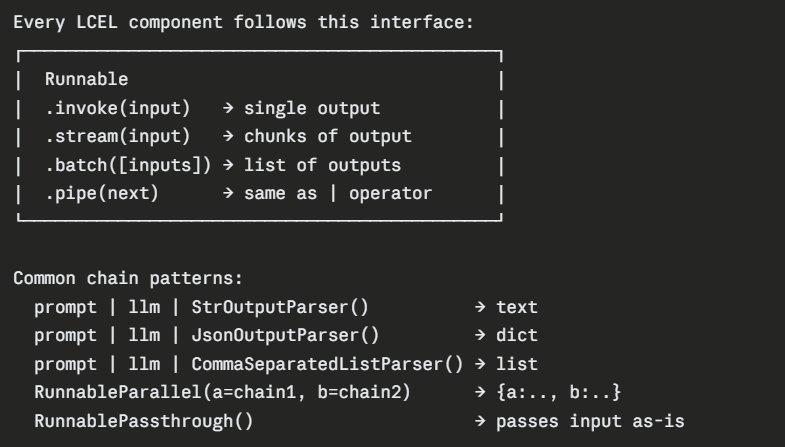